In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
class Lor_reservoir:
    def __init__(self, hyperparameters):
        self.num_neurons = hyperparameters.get("num_neurons")
        self.input_connectivity = hyperparameters.get("input_connectivity")
        self.num_steps = hyperparameters.get("num_steps")
        self.input_firing_rate = hyperparameters.get("input_firing_rate")
        self.weight_connectivity = hyperparameters.get("weight_connectivity")
        self.LIF_beta = hyperparameters.get("LIF_beta")
        self.LIF_threshold = hyperparameters.get("LIF_threshold")
        

    def init_weights(self, target_sr):

        # weight matrix for reservoir. Weights drawn from gaussian with mean 0 and std 0.333s, and with 10% connectivity.
        # includes exitatory and inhibitory weights.
        w_res = np.random.normal(0, 0.333, (self.num_neurons, self.num_neurons))

        mask = np.random.rand(self.num_neurons, self.num_neurons) < self.weight_connectivity
        w_res = w_res * mask
        np.fill_diagonal(w_res, 0) # no self-connections

        eigenvalues = np.linalg.eigvals(w_res)
        current_sr = np.max(np.abs(eigenvalues))

        #TODO more on this
        if current_sr > 0: 
            w_res = w_res / current_sr * target_sr

        return w_res
        

    def init_input_weights_full(self, input_dim):
        # shape: (num_neurons, input_dim)
        # random signs and magnitudes, sparse by input_connectivity
        w_in = np.random.uniform(-1, 1, (self.num_neurons, input_dim))
        mask = np.zeros((self.num_neurons, input_dim))
        input_neurons = np.random.choice(
            self.num_neurons,
            size=int(self.num_neurons * self.input_connectivity),
            replace=False
        )
        mask[input_neurons, :] = 1.0
        return w_in * mask

    def gen_spikes(self, rate_tensor):
        random_vals = np.random.random(rate_tensor.shape)
        spikes = (random_vals < rate_tensor).astype(float)
        return spikes
    

    def LIF_res(self, prev_mem, prev_spk, w_res, input_spikes, beta, threshold):

        recurrent_input = w_res @ prev_spk  # (num_neurons,)
        
        total_input = input_spikes + recurrent_input # (num_neurons,)

        spk = (prev_mem > threshold).astype(float)
        mem = beta * prev_mem + total_input - spk * threshold
        
        return mem, spk

In [3]:
def generate_lorenz(num_steps, dt=0.01, sigma=10, rho=28, beta=8/3):
    xyz = np.zeros((num_steps, 3))
    xyz[0] = [1.0, 1.0, 1.0]  # initial condition
    for t in range(num_steps - 1):
        x, y, z = xyz[t]
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        xyz[t+1] = xyz[t] + dt * np.array([dx, dy, dz])
    return xyz

In [4]:
def train_readout_ridge(X_train, Y_train, alpha=1e-4):

    # X_train: (T, N)
    # Y_train: (T, 3)
    T, N = X_train.shape
    w_out = Y_train.T @ X_train @ np.linalg.inv(X_train.T @ X_train + alpha * np.eye(N))
    return w_out  # (3, N)

In [5]:
def nrmse(y_true, y_pred):
    # y_true, y_pred: (T, 3)
    error = np.sqrt(np.mean((y_true - y_pred)**2, axis=0))
    scale = np.std(y_true, axis=0)
    return error / scale  # (3,) — one per coordinate


## Normalization

The Lorenz attractor's three dimensions do not share the same scale. In particular, $z$ has a significantly higher mean and variance than $x$ and $y$, which causes the readout to prioritize it and perform relatively worse on the others.

Normalizing each dimension to zero mean and unit variance before feeding the trajectory into the reservoir (and before computing the readout targets) removes this bias and leads to more balanced prediction across all three dimensions.

Mean and std are saved from the training data and can be used to recover the original scale if needed.

In [6]:
def normalize_lorenz(traj):
    mean = traj.mean(axis=0)       # (3,)
    std  = traj.std(axis=0)        # (3,)
    return (traj - mean) / std, mean, std

In [7]:
washout_steps = 200
train_steps   = 2000
test_steps    = 300
total_steps   = washout_steps + train_steps + test_steps  # 1200


hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.9,
    "LIF_threshold": 1.0,
}


num_neurons = hp['num_neurons']
num_steps = hp['num_steps']

res = Lor_reservoir(hp)

spectral_lambdas = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5]

score_arr = []


for lam in spectral_lambdas:
    print(10*"#")
    print(f"for sr lambda {lam}")

    w_in_weights = res.init_input_weights_full(3) # (num_neurons, 3)
    w_res = res.init_weights(lam)

    lorenz_traj = generate_lorenz(num_steps, dt=0.01) # (num_steps, 3)
    lorenz_norm, lorenz_mean, lorenz_std = normalize_lorenz(lorenz_traj)


    mem = np.zeros(num_neurons)
    spk = np.zeros(num_neurons)
    spk_rec = np.zeros((num_steps, num_neurons))
    mem_rec = np.zeros((num_steps, num_neurons))

    print(f"ready to sim")

    for t in range(num_steps):

        I = w_in_weights @ lorenz_norm[t] # (100, )

        mem, spk = res.LIF_res(mem, spk, w_res, I, hp["LIF_beta"], hp["LIF_threshold"])
        spk_rec[t] = spk
        mem_rec[t] = mem


    X_train = spk_rec[washout_steps : washout_steps + train_steps]    # (T, N)
    Y_train = lorenz_norm[washout_steps+1 : washout_steps + train_steps+1]  # (T, 3)

    X_test = spk_rec[washout_steps + train_steps : total_steps - 1]   # (T, N)
    Y_test = lorenz_norm[washout_steps + train_steps+1 : total_steps]  # (T, 3)

    print(f"ready to train")

    # train
    w_out = train_readout_ridge(X_train, Y_train, alpha=1e-4)  # (3, N)

    # predict
    Y_pred = (w_out @ X_test.T).T   # (T, 3)

    Y_pred_denorm = Y_pred * lorenz_std + lorenz_mean
    Y_test_denorm = Y_test * lorenz_std + lorenz_mean

    scores = nrmse(Y_test_denorm, Y_pred_denorm)
    score_arr.append(scores)



##########
for sr lambda 0.5
ready to sim
ready to train
##########
for sr lambda 0.7
ready to sim
ready to train
##########
for sr lambda 0.9
ready to sim
ready to train
##########
for sr lambda 1.0
ready to sim
ready to train
##########
for sr lambda 1.1
ready to sim
ready to train
##########
for sr lambda 1.3
ready to sim
ready to train
##########
for sr lambda 1.5
ready to sim
ready to train


In [8]:
print("mean firing rate:", spk_rec[washout_steps:].mean())
print("fraction silent neurons:", (spk_rec[washout_steps:].mean(axis=0) == 0).mean())

mean firing rate: 0.16067391304347825
fraction silent neurons: 0.12


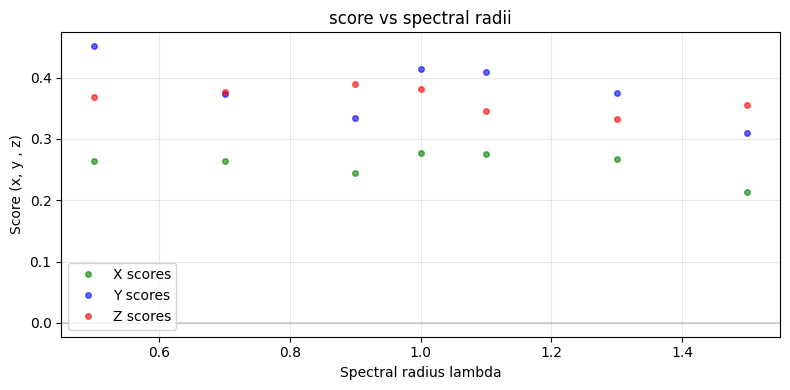

In [9]:
# Create visualization
plt.figure(figsize=(8, 4))

# Plot 1: Scatter plot of all samples
plt.plot(spectral_lambdas, [x[0] for x in score_arr], 'o', alpha=0.6, markersize=4, color="green", label='X scores')
plt.plot(spectral_lambdas, [y[1] for y in score_arr], 'o', alpha=0.6, markersize=4, color="blue", label='Y scores')
plt.plot(spectral_lambdas, [z[2] for z in score_arr], 'o', alpha=0.6, markersize=4, color="red", label='Z scores')

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Spectral radius lambda')
plt.ylabel('Score (x, y , z)')
plt.title('score vs spectral radii')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Averaging over multiple networks

In [10]:
washout_steps = 200
train_steps   = 2000
test_steps    = 500
total_steps   = washout_steps + train_steps + test_steps  # 1200


hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.9,
    "LIF_threshold": 1.0,
}


num_neurons = hp['num_neurons']
num_steps = hp['num_steps']

res = Lor_reservoir(hp)

spectral_lambdas = list(np.arange(0, 20, 0.3))

weight_scale = 1

score_tensor = []

num_trials = 5

for i in range(num_trials):
    print(10*"-")
    print(f"Trial {i}")

    score_arr = []

    for lam in spectral_lambdas:
        #print(10*"#")
        #print(f"for sr lambda {lam}")

        w_in_weights = res.init_input_weights_full(3) * weight_scale # (num_neurons, 3)
        w_res = res.init_weights(lam)

        lorenz_traj = generate_lorenz(num_steps, dt=0.01) # (num_steps, 3)
        lorenz_norm, lorenz_mean, lorenz_std = normalize_lorenz(lorenz_traj)


        mem = np.zeros(num_neurons)
        spk = np.zeros(num_neurons)
        spk_rec = np.zeros((num_steps, num_neurons))
        mem_rec = np.zeros((num_steps, num_neurons))

        #print(f"ready to sim")

        for t in range(num_steps):

            I = w_in_weights @ lorenz_norm[t] # (100, )

            mem, spk = res.LIF_res(mem, spk, w_res, I, hp["LIF_beta"], hp["LIF_threshold"])
            spk_rec[t] = spk
            mem_rec[t] = mem


        X_train = spk_rec[washout_steps : washout_steps + train_steps]    # (T, N)
        Y_train = lorenz_norm[washout_steps+1 : washout_steps + train_steps+1]  # (T, 3)

        X_test = spk_rec[washout_steps + train_steps : total_steps - 1]   # (T, N)
        Y_test = lorenz_norm[washout_steps + train_steps+1 : total_steps]  # (T, 3)

        #print(f"ready to train")

        # train
        w_out = train_readout_ridge(X_train, Y_train, alpha=1e-4)  # (3, N)

        # predict
        Y_pred = (w_out @ X_test.T).T   # (T, 3)

        Y_pred_denorm = Y_pred * lorenz_std + lorenz_mean
        Y_test_denorm = Y_test * lorenz_std + lorenz_mean

        # score
        scores = nrmse(Y_test_denorm, Y_pred_denorm)

        score_arr.append(scores)

    score_tensor.append(score_arr) # (num_trials, num_lambdas, 3)

# average over trials
avg_scores = np.mean(score_tensor, axis=0)  # (num_lambdas, 3)
std_scores = np.std(score_tensor, axis=0)   # (num_lambdas, 3)

----------
Trial 0
----------
Trial 1
----------
Trial 2
----------
Trial 3
----------
Trial 4


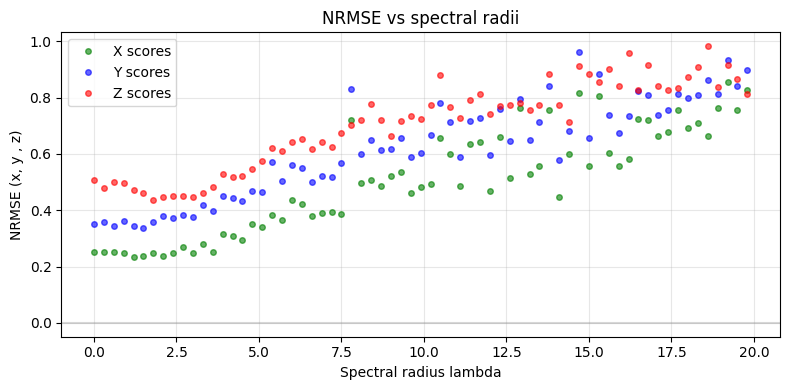

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(spectral_lambdas, [x[0] for x in avg_scores], 'o', alpha=0.6, markersize=4, color="green", label='X scores')
plt.plot(spectral_lambdas, [y[1] for y in avg_scores], 'o', alpha=0.6, markersize=4, color="blue", label='Y scores')
plt.plot(spectral_lambdas, [z[2] for z in avg_scores], 'o', alpha=0.6, markersize=4, color="red", label='Z scores')

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Spectral radius lambda')
plt.ylabel('NRMSE (x, y , z)')
plt.title('NRMSE vs spectral radii')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()